## Update a Wflow model: gauging stations

Once you have a **Wflow** model, you may want to update your model in order to use a new landuse map, change a parameter value, add sample locations, use different forcing data, create and run different scenarios etc.

With HydroMT, you can easily read your model and update one or several components of your model using the **update** function of the command line interface (CLI). Here are the steps and some examples on how to **update/add gauging stations** to your model.

All lines in this notebook which starts with ! are executed from the command line. Within the notebook environment the logging messages are shown after completion. You can also copy these lines and paste them in your shell to get more feedback.

### Import packages

In this notebook, we will use some functions of HydroMT to plot the new gauging stations of the updated model. Here are the libraries to import to realize these steps.

In [2]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box

In [3]:
# for plotting
import matplotlib.pyplot as plt
import cartopy.io.img_tiles as cimgt
import cartopy.crs as ccrs

proj = ccrs.PlateCarree()  # plot projection

### Locations of the gauging stations

Adding gauging stations to your **Wflow** model can be quite useful. It allows you to directly extract model outputs at specific locations. For example for model validation, calibration, you can then directly compare model results to available observations.

In our previous notebook, we built a wflow model in which the locations of the available [GRDC](https://waterandchange.org/en/grdc-data-download-provides-river-discharge-data-online/) stations are including. If you have other observation data available, you can easily add them to your model using HydroMT. One way to do it is to prepare a csv table containing the ID, latitude and longitude of the available stations. An example **test_stations.csv** has been prepared. Let's have a look at it. 

In [4]:
fn_station = "test_stations.csv"
with open(fn_station, "r", encoding="utf8") as f:
    txt = f.read()
print(txt)

ID,Name,x,y,uparea
1001,Gauge1,11.9594,45.8925,3642
1002,Gauge2,12.3395,46.1492,2
1003,Gauge3,12.0785,46.1122,837



Here we can see that we have defined three stations with an ID and the longitude (x) and latitude (y) coordinates, in the same EPSG system as our model (EPSG 4326). We can now add them to our model.

### HydroMT CLI update interface

Using the **HydroMT build** API, we can update one or several components of an already existing Wflow model. Let's get an overview of the available options:

In [5]:
# Print the options available from the update command
! hydromt update --help

Usage: hydromt update [OPTIONS] MODEL MODEL_ROOT

  Update a specific component of a model.

  Set an output directory to copy the edited model to a new folder, otherwise
  maps are overwritten.

  Example usage: --------------

  Update Wflow model components outlined in an .yml configuration file and
  write the model to a directory: hydromt update wflow_sbm /path/to/model_root
  -o /path/to/model_out  -i /path/to/wflow_config.yml  -d
  /path/to/data_catalog.yml -v

Options:
  -o, --model-out DIRECTORY  Output model folder. Maps in MODEL_ROOT are
                             overwritten if left empty.
  -i, --config PATH          Path to hydroMT configuration file, for the model
                             specific implementation.  [required]
  -d, --data TEXT            Path to local yaml data catalog file OR name of
                             predefined data catalog.
  --dd, --deltares-data      Flag: Shortcut to add the "deltares_data" catalog
  --fo, --force-overwrite    Flag:

### Update Wflow gauging stations

Let's open the example configuration file (**wflow_update_gauges.yml**) from the model repository [examples folder] and have a look at the setup_gauges step.

In [6]:
fn_config = "wflow_update_gauges.yml"
with open(fn_config, "r") as f:
    txt = f.read()
print(txt)

steps:
  - setup_gauges:
      gauges_fn : test_stations.csv
      basename: test-flow



Here, you see the step for updating the gauges with our test_stations.csv and giving it the name **test-flow**.
Let's update the model with the following CLI command:

In [7]:
# NOTE: copy this line (without !) to your shell for more direct feedback
! hydromt update wflow_sbm wflow_piave_subbasin -o ./wflow_piave_gauges -i wflow_update_gauges.yml -v

2026-03-09 14:59:24,855 - hydromt - log - INFO - HydroMT version: 1.3.0
2026-03-09 14:59:24,918 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 14:59:24,919 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 14:59:24,969 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 14:59:24,969 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_subbasin/wflow_sbm.toml.
2026-03-09 14:59:24,971 - hydromt - log - INFO - HydroMT version: 1.3.0
2026-03-09 14:59:24,972 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesi

The example above means the following: run **hydromt** with:

- `update wflow`: i.e. update a wflow model
- `wflow_piave_subbasin`: original model folder
- `-o ./wflow_piave_gauges`: output updated model folder
- `-i wflow_update_gauges.yml`: path to the update configuration file. 
- `v`: give some extra verbosity (2 * v) to display feedback on screen. Now debug messages are provided.

Other available options are available in the [docs (setup gauges)](https://deltares.github.io/hydromt_wflow/latest/_generated/hydromt_wflow.WflowBaseModel.setup_gauges.html).

### Update Wflow gauging stations without snapping

By default, the **setup_gauges** of HydroMT Wflow will assume that gauges are for flow sampling and will therefore snap the gauges locations to the river. If your observations are used to compare rainfall data, then you do not want HydroMT to move the location of your gauges. This is done by setting `snap_to_river: False`.

By default, HydroMT Wflow will update the TOML in order to save both river discharge and precipitation at the new gauges locations. With our rainfall stations, we only need to save the precipitation. We can set this with hydroMT using the options:

- `gauge_toml_header: ['P-station']`: set the column name in the outputcsv file of the Wflow run in the TOML configuration
- `gauge_toml_param: ['atmosphere_water__precipitation_volume_flux']`: set the Wflow variable to save in the corresponding outputcsv file column of Wflow run in the TOML configuration 

In [8]:
fn_config = "wflow_update_gauges_without_snapping.yml"
with open(fn_config, "r") as f:
    txt = f.read()
print(txt)

steps:
  - setup_gauges:
      gauges_fn : test_stations.csv
      basename: test-rain
      snap_to_river: False
      gauge_toml_header: ['P-station']
      gauge_toml_param : ['atmosphere_water__precipitation_volume_flux']



In [9]:
# NOTE: copy this line (without !) to your shell for more direct feedback
! hydromt update wflow_sbm wflow_piave_gauges -i wflow_update_gauges_without_snapping.yml -v

2026-03-09 14:59:34,034 - hydromt - log - INFO - HydroMT version: 1.3.0
2026-03-09 14:59:34,091 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 14:59:34,092 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 14:59:34,139 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 14:59:34,139 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_gauges/wflow_sbm.toml.
2026-03-09 14:59:34,141 - hydromt - log - INFO - HydroMT version: 1.3.0
2026-03-09 14:59:34,141 - hydromt - log - INFO - HydroMT version: 1.3.0
2026-03-09 14:59:36,306 - hydromt.model.model - model - INFO - update: setup_gauges
2026-03-09 1

The example above means the following: run **hydromt** with:

- `update wflow`: i.e. update a wflow model
- `wflow_piave_gauges`: model folder to update (here we save our updates in the same model folder)
- `-i wflow_update_gauges_without_snapping.yml`: the config yaml containing the additional options.
- `v`: give some extra verbosity (2 * v) to display feedback on screen. Now debug messages are provided.

Other available options are available in the [docs (setup gauges)](https://deltares.github.io/hydromt_wflow/latest/_generated/hydromt_wflow.WflowBaseModel.setup_gauges.html).



### Visualization of the gauges

We can now plot our newly created gauges stations maps and check the differences between the flow and rain maps.

In [10]:
# Load the updated model with hydromt
from hydromt_wflow import WflowSbmModel

mod = WflowSbmModel(root="wflow_piave_gauges", mode="r")

2026-03-09 14:59:41,467 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 14:59:41,469 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from c:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 14:59:41,546 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 14:59:41,547 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_gauges/wflow_sbm.toml.


In [11]:
# read/derive river geometries
gdf_riv = mod.rivers
# read/derive model basin boundary
gdf_bas = mod.basins

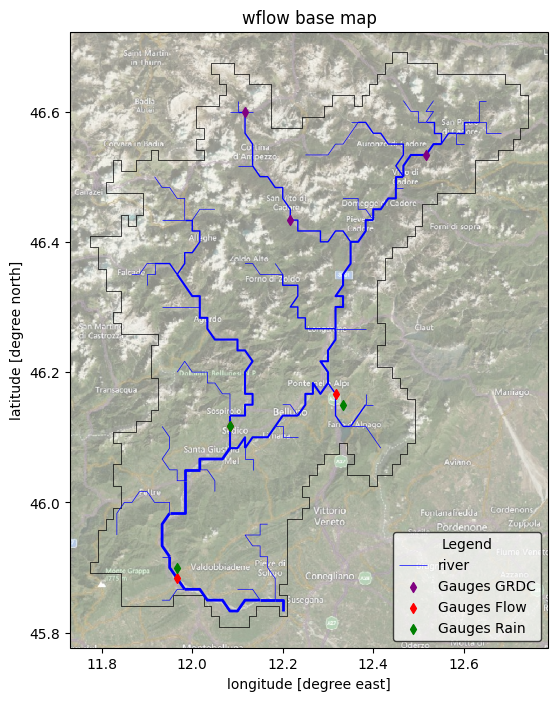

In [12]:
# Plot
# we assume the model maps are in the geographic CRS EPSG:4326
proj = ccrs.PlateCarree()
# adjust zoomlevel and figure size to your basis size & aspect
zoom_level = 10
figsize = (10, 8)
shaded = False

# initialize image with geoaxes
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(projection=proj)
bounds = mod.region.total_bounds
bbox = gpd.GeoDataFrame(geometry=[box(*bounds)], crs=mod.crs).to_crs(3857).buffer(5e3)
extent = np.array(bbox.to_crs(mod.crs).total_bounds)[[0, 2, 1, 3]]
ax.set_extent(extent, crs=proj)

# add sat background image
ax.add_image(cimgt.QuadtreeTiles(), zoom_level, alpha=0.5)

# plot rivers with increasing width with stream order
gdf_riv.plot(ax=ax, lw=gdf_riv["strord"] / 2, color="blue", zorder=3, label="river")
# plot the basin boundary
gdf_bas.boundary.plot(ax=ax, color="k", linewidth=0.5)
if "gauges" in mod.geoms.data:
    mod.geoms.get("gauges").plot(
        ax=ax, marker="d", markersize=25, facecolor="k", zorder=5, label="outlet"
    )
if "gauges_grdc" in mod.geoms.data:
    mod.geoms.get("gauges_grdc").plot(
        ax=ax,
        marker="d",
        markersize=25,
        facecolor="purple",
        zorder=5,
        label="Gauges GRDC",
    )
if "gauges_test-flow" in mod.geoms.data:
    mod.geoms.get("gauges_test-flow").plot(
        ax=ax, marker="d", markersize=25, facecolor="red", zorder=5, label="Gauges Flow"
    )
if "gauges_test-rain" in mod.geoms.data:
    mod.geoms.get("gauges_test-rain").plot(
        ax=ax,
        marker="d",
        markersize=25,
        facecolor="green",
        zorder=5,
        label="Gauges Rain",
    )

ax.xaxis.set_visible(True)
ax.yaxis.set_visible(True)
ax.set_ylabel(f"latitude [degree north]")
ax.set_xlabel(f"longitude [degree east]")
_ = ax.set_title(f"wflow base map")
legend = ax.legend(
    handles=[*ax.get_legend_handles_labels()[0]],
    title="Legend",
    loc="lower right",
    frameon=True,
    framealpha=0.7,
    edgecolor="k",
    facecolor="white",
)